# Análise da Rede de Emails da Enron
## Modelagem como Grafo não Direcionado

In [3]:
import gzip
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
!pip install powerlaw
import powerlaw
!pip install algs4
from algs4.bag import Bag

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached algs4-1.0.3-py3-none-any.whl.metadata (3.7 kB)
Using cached algs4-1.0.3-py3-none-any.whl (58 kB)



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Classe Graph

In [4]:
class Graph:
    """
    Grafo não direcionado representado por listas de adjacência com Bag.
    Cada vértice representa um nó.
    Cada aresta (v, w) representa uma conexão entre v e w.
    Como o grafo é não direcionado:
    - w entra na adjacência de v
    - v entra na adjacência de w
    Observação:
    - Bag não impede duplicatas
    - por isso, o tratamento de duplicatas será feito na leitura do arquivo
    """
    
    def __init__(self, V):
        self._V = V
        self._E = 0
        self.adj = [Bag() for _ in range(V)]
    
    def V(self):
        return self._V
    
    def E(self):
        return self._E
    
    def add_edge(self, v, w):
        """
        Adiciona uma aresta não direcionada entre v e w.
        """
        self.adj[v].add(w)
        self.adj[w].add(v)
        self._E += 1
    
    def degree(self, v):
        """
        Retorna o grau do vértice v.
        """
        count = 0
        for _ in self.adj[v]:
            count += 1
        return count
    
    def neighbors(self, v):
        """
        Retorna a lista de vizinhos de v.
        """
        return sorted(list(self.adj[v]))
    
    def degrees_array(self, remove_zeros=False):
        """
        Retorna um array com os graus de todos os vértices.
        """
        deg = np.array([self.degree(v) for v in range(self._V)], dtype=int)
        if remove_zeros:
            return deg[deg > 0]
        return deg
    
    def density(self):
        """
        Densidade de um grafo não direcionado simples: D = 2E / (V(V-1))
        """
        if self._V <= 1:
            return 0.0
        return (2 * self._E) / (self._V * (self._V - 1))
    
    def avg_degree(self):
        """
        Grau médio de um grafo não direcionado: grau_medio = 2E / V
        """
        if self._V == 0:
            return 0.0
        return (2 * self._E) / self._V
    
    def local_clustering(self, v):
        """
        Coeficiente de clustering local do vértice v:
        C(v) = 2 * número de ligações entre vizinhos / (k * (k - 1))
        Se grau < 2, retorna 0.
        """
        neighbors = list(self.adj[v])
        k = len(neighbors)
        if k < 2:
            return 0.0
        
        links_between_neighbors = 0
        for i in range(k):
            u = neighbors[i]
            for j in range(i + 1, k):
                w = neighbors[j]
                if w in self.neighbors_set(u):
                    links_between_neighbors += 1
        return (2 * links_between_neighbors) / (k * (k - 1))
    
    def neighbors_set(self, v):
        """
        Retorna os vizinhos de v em formato set.
        Útil para testes de pertinência no clustering.
        """
        return set(self.adj[v])
    
    def average_clustering(self):
        """
        Coeficiente de clustering médio do grafo.
        """
        if self._V == 0:
            return 0.0
        values = [self.local_clustering(v) for v in range(self._V)]
        return float(np.mean(values))

## 2. Funções de Carregamento e Métricas

Carregamento do arquivo do dataset.

Tratado pois a partir do dataset ele aponta para a mesma aresta 1 0  e 0 1.

Mesmo sendo não direcionado (como comprovado na descrição do mesmo)
"Nodes of the network are email addresses and if an address i sent at least one email to address j, the graph contains an undirected edge from i to j."

E comprovado aqui
"Nodes	36692
Edges	183831"
pois se não tratar o arquivo ele vem com o dobro de arestas do que era para ser, indicando justamente a duplicata do arquivo.

Porém no arquivo vem com duplicata
Que foi tratada aqui.  

In [5]:
def load_graph_from_gz(filename):
    """
    Lê o arquivo .gz e monta o grafo não direcionado com Bag.
    Como o dataset da Enron traz as conexões nos dois sentidos:
        u v
        v u
    fazemos o tratamento de duplicatas na leitura, usando uma forma canônica da aresta:
        (min(u, v), max(u, v))
    Assim, cada aresta não direcionada entra apenas uma vez.
    """
    edges = []
    seen = set()
    max_node = 0
    
    with gzip.open(filename, "rt", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            v, w = map(int, line.split())
            # ignora auto-laços
            if v == w:
                continue
            # normaliza a aresta para não direcionado
            edge = (min(v, w), max(v, w))
            if edge not in seen:
                seen.add(edge)
                edges.append(edge)
                max_node = max(max_node, v, w)
    
    g = Graph(max_node + 1)
    for v, w in edges:
        g.add_edge(v, w)
    return g

def print_basic_metrics(g):
    """
    Imprime as métricas básicas do grafo.
    """
    degrees_all = g.degrees_array(remove_zeros=False)
    degrees_nonzero = g.degrees_array(remove_zeros=True)
    
    print("=" * 60)
    print("MÉTRICAS BÁSICAS DO GRAFO")
    print("=" * 60)
    print("Modelagem adotada: grafo não direcionado e não ponderado")
    print(f"|V| (número de vértices): {g.V()}")
    print(f"|E| (número de arestas): {g.E()}")
    print(f"Densidade: {g.density():.8f}")
    print(f"Grau médio: {g.avg_degree():.4f}")
    print(f"Clustering médio: {g.average_clustering():.6f}")
    print()
    
    soma_graus = degrees_all.sum()
    print(f"Soma dos graus: {soma_graus}")
    print(f"Verificação do lema do aperto de mãos: 2|E| = {2 * g.E()}")
    print()
    
    print("Resumo dos graus (todos os vértices):")
    print(f"  Mínimo: {degrees_all.min()}")
    print(f"  Mediana: {int(np.median(degrees_all))}")
    print(f"  Média: {degrees_all.mean():.4f}")
    print(f"  Máximo: {degrees_all.max()}")
    print()
    
    print("Resumo dos graus (apenas graus > 0):")
    print(f"  Quantidade de vértices conectados: {len(degrees_nonzero)}")
    print(f"  Mínimo: {degrees_nonzero.min()}")
    print(f"  Mediana: {int(np.median(degrees_nonzero))}")
    print(f"  Média: {degrees_nonzero.mean():.4f}")
    print(f"  Máximo: {degrees_nonzero.max()}")
    print()

def inspect_vertices(g, vertices):
    """
    Inspeção manual de alguns vértices.
    Útil para validar a modelagem e explicar na apresentação.
    """
    print("=" * 60)
    print("INSPEÇÃO MANUAL DE VÉRTICES")
    print("=" * 60)
    for v in vertices:
        if v < 0 or v >= g.V():
            print(f"Vértice {v}: fora do intervalo válido.")
            continue
        vizinhos = g.neighbors(v)
        print(f"Vértice {v}")
        print(f"  Grau: {g.degree(v)}")
        print(f"  Clustering local: {g.local_clustering(v):.6f}")
        print(f"  Vizinhos (até 15): {vizinhos[:15]}")
        print()

## 3. Funções para Análise da Distribuição de Graus

In [6]:
def degree_distribution_pk(degrees):
    """
    Retorna a distribuição de graus P(k), isto é,
    a probabilidade de um vértice ter grau k.
    """
    freq = Counter(degrees)
    total = len(degrees)
    k_vals = np.array(sorted(freq.keys()), dtype=int)
    pk_vals = np.array([freq[k] / total for k in k_vals], dtype=float)
    return k_vals, pk_vals

def plot_degree_distribution_linear(degrees, title, save_path=None):
    """
    Plota a distribuição de graus P(k) em escala linear.
    Eixo X: grau k
    Eixo Y: P(k) = frequência relativa
    """
    k_vals, pk_vals = degree_distribution_pk(degrees)
    
    plt.figure(figsize=(10, 6))
    plt.bar(k_vals, pk_vals, width=0.9, alpha=0.85, edgecolor="black")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Grau (k)")
    plt.ylabel("P(k)")
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

def plot_loglog(degrees, title, save_path=None):
    """
    Plota a distribuição de graus P(k) em escala log-log.
    Eixo X: grau k
    Eixo Y: P(k)
    Ambos em escala logarítmica.
    """
    k_vals, pk_vals = degree_distribution_pk(degrees)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(k_vals, pk_vals, s=20, alpha=0.85, label="P(k) observada")
    plt.xscale("log")
    plt.yscale("log")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Grau (k) [escala log]")
    plt.ylabel("P(k) [escala log]")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

def fit_powerlaw(degrees):
    """
    Ajusta uma lei de potência aos graus positivos.
    Retorna:
    - fit
    - gamma
    - xmin
    - sigma
    - ks
    - n_tail
    """
    fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    xmin = fit.power_law.xmin
    sigma = fit.power_law.sigma
    ks = getattr(fit.power_law, "D", None)
    if ks is None:
        ks = fit.power_law.KS()
    n_tail = int(np.sum(np.array(degrees) >= xmin))
    return fit, gamma, xmin, sigma, ks, n_tail

def plot_loglog_with_fit(degrees, fit, ks, n_tail, title, save_path=None):
    """
    Plota P(k) em log-log com linha visual do ajuste de power law.
    """
    k_vals, pk_vals = degree_distribution_pk(degrees)
    gamma = fit.power_law.alpha
    xmin = fit.power_law.xmin
    sigma = fit.power_law.sigma
    
    mask = k_vals >= xmin
    k_sel = k_vals[mask]
    pk_sel = pk_vals[mask]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(k_vals, pk_vals, s=20, alpha=0.85, label="P(k) empírica")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(alpha=0.25)
    
    if len(k_sel) >= 2:
        k0 = float(k_sel[0])
        p0 = float(pk_sel[0])
        C = p0 * (k0 ** gamma)
        k_line = np.linspace(k_sel.min(), k_sel.max(), 400)
        pk_line = C * (k_line ** (-gamma))
        plt.plot(
            k_line, pk_line, linewidth=2.2,
            label=f"Ajuste visual power law (γ = {gamma:.3f})",
        )
    
    plt.axvline(xmin, linestyle="--", linewidth=1.5, label=f"xmin = {xmin}")
    
    info_text = (
        f"γ = {gamma:.3f}\n"
        f"xmin = {xmin}\n"
        f"sigma = {sigma:.3f}\n"
        f"KS = {ks:.4f}\n"
        f"n_cauda = {n_tail}"
    )
    
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Grau (k)")
    plt.ylabel("P(k)")
    plt.text(
        0.97, 0.97, info_text,
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", alpha=0.15),
    )
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

def print_scale_free_conclusion(gamma, xmin, ks, n_tail):
    """
    Imprime uma discussão inicial sobre o ajuste de power law.
    """
    print("=" * 60)
    print("DISCUSSÃO INICIAL SOBRE A LEI DE POTÊNCIA")
    print("=" * 60)
    print("A classificação como escala livre não deve ser feita apenas pela aparência do gráfico log-log.")
    print("É importante observar o ajuste estatístico e o tamanho da cauda.")
    print()
    print(f"γ estimado: {gamma:.4f}")
    print(f"xmin: {xmin}")
    print(f"KS: {ks:.4f}")
    print(f"n_cauda: {n_tail}")
    print()
    print("Conclusão inicial:")
    print("A distribuição apresenta uma cauda que pode ser analisada por meio de lei de potência.")
    print("Mesmo assim, isso não significa automaticamente que toda a rede seja perfeitamente escala livre.")
    print("A interpretação correta é dizer que há um ajuste de power law na cauda da distribuição de graus.")
    print()

## 4. Execução Principal

In [7]:
# Carregar o grafo
nome_arquivo = "email-Enron.txt.gz"
print(f"Abrindo arquivo: {nome_arquivo}...")
g = load_graph_from_gz(nome_arquivo)

# Obter arrays de graus
degrees_all = g.degrees_array(remove_zeros=False)
degrees_nonzero = g.degrees_array(remove_zeros=True)

Abrindo arquivo: email-Enron.txt.gz...


In [15]:
# Métricas básicas
print_basic_metrics(g)

MÉTRICAS BÁSICAS DO GRAFO
Modelagem adotada: grafo não direcionado e não ponderado
|V| (número de vértices): 36692
|E| (número de arestas): 183831
Densidade: 0.00027310
Grau médio: 10.0202
Clustering médio: 0.496983

Soma dos graus: 367662
Verificação do lema do aperto de mãos: 2|E| = 367662

Resumo dos graus (todos os vértices):
  Mínimo: 1
  Mediana: 3
  Média: 10.0202
  Máximo: 1383

Resumo dos graus (apenas graus > 0):
  Quantidade de vértices conectados: 36692
  Mínimo: 1
  Mediana: 3
  Média: 10.0202
  Máximo: 1383



In [9]:
# Inspeção manual de vértices
inspect_vertices(g, [0, 1, 2, 3, 10])

INSPEÇÃO MANUAL DE VÉRTICES
Vértice 0
  Grau: 1
  Clustering local: 0.000000
  Vizinhos (até 15): [1]

Vértice 1
  Grau: 70
  Clustering local: 0.013665
  Vizinhos (até 15): [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Vértice 2
  Grau: 1
  Clustering local: 0.000000
  Vizinhos (até 15): [1]

Vértice 3
  Grau: 5
  Clustering local: 0.600000
  Vizinhos (até 15): [1, 4, 6, 878, 8552]

Vértice 10
  Grau: 4
  Clustering local: 1.000000
  Vizinhos (até 15): [1, 11, 12, 13]



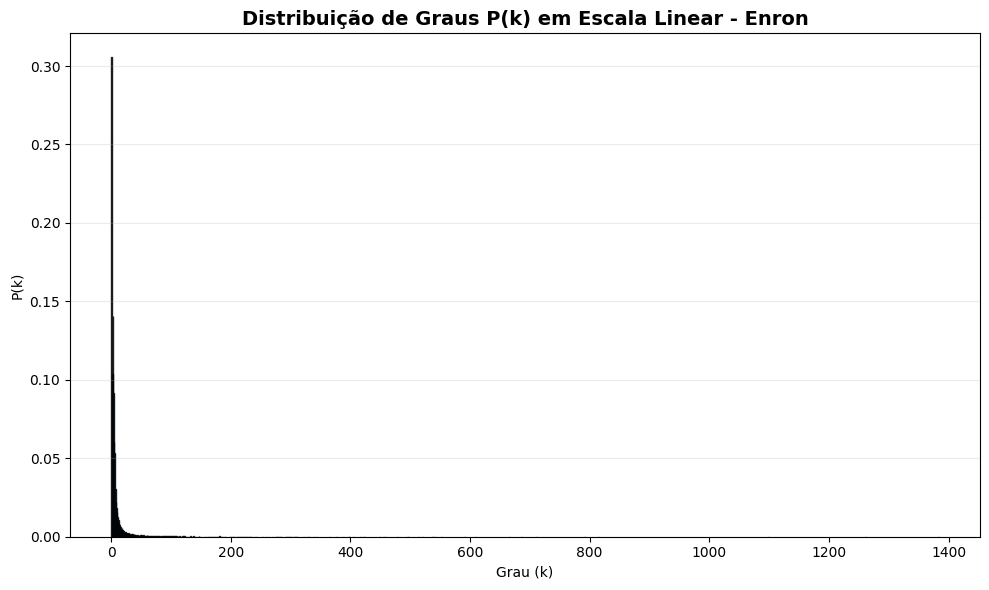

In [10]:
# Gráfico 1: distribuição de graus em escala linear
plot_degree_distribution_linear(
    degrees_nonzero,
    "Distribuição de Graus P(k) em Escala Linear - Enron",
    "degree_distribution_linear_enron.png"
)

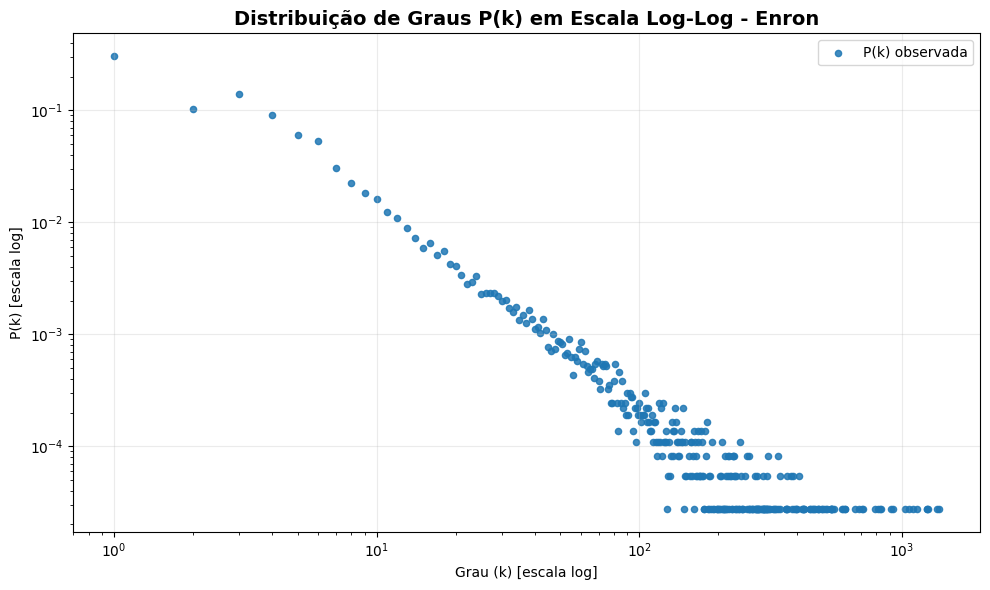

In [11]:
# Gráfico 2: distribuição de graus em escala log-log
plot_loglog(
    degrees_nonzero,
    "Distribuição de Graus P(k) em Escala Log-Log - Enron",
    "loglog_enron_undirected.png"
)

In [12]:
# Ajuste power law
fit, gamma, xmin, sigma, ks, n_tail = fit_powerlaw(degrees_nonzero)

print("=" * 60)
print("AJUSTE DE LEI DE POTÊNCIA")
print("=" * 60)
print(f"gamma = {gamma:.4f}")
print(f"xmin = {xmin}")
print(f"sigma = {sigma:.4f}")
print(f"KS = {ks:.4f}")
print(f"n_cauda = {n_tail}")
print()

AJUSTE DE LEI DE POTÊNCIA
gamma = 1.9725
xmin = 4.0
sigma = 0.0076
KS = 0.0155
n_cauda = 16514



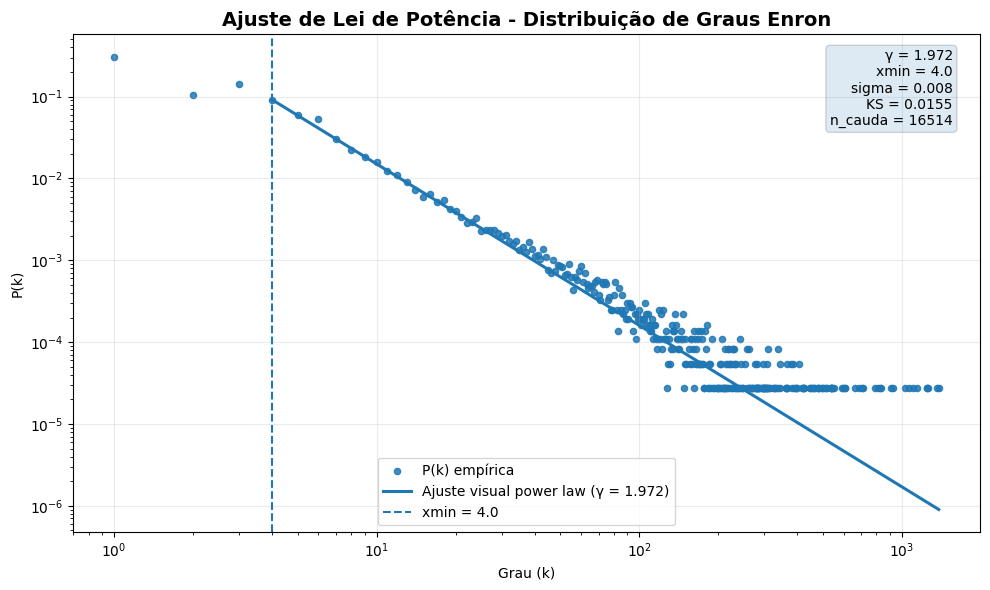

In [13]:
# Gráfico 3: log-log com ajuste
plot_loglog_with_fit(
    degrees_nonzero,
    fit,
    ks,
    n_tail,
    "Ajuste de Lei de Potência - Distribuição de Graus Enron",
    "powerlaw_fit_enron_undirected.png"
)

In [14]:
# Conclusão inicial
print_scale_free_conclusion(gamma, xmin, ks, n_tail)

DISCUSSÃO INICIAL SOBRE A LEI DE POTÊNCIA
A classificação como escala livre não deve ser feita apenas pela aparência do gráfico log-log.
É importante observar o ajuste estatístico e o tamanho da cauda.

γ estimado: 1.9725
xmin: 4.0
KS: 0.0155
n_cauda: 16514

Conclusão inicial:
A distribuição apresenta uma cauda que pode ser analisada por meio de lei de potência.
Mesmo assim, isso não significa automaticamente que toda a rede seja perfeitamente escala livre.
A interpretação correta é dizer que há um ajuste de power law na cauda da distribuição de graus.

